# Task
Use Zero-shot and Few-Shot using llama3.2 and evaluate the results on both the `test_easy` and `test_hard` sets.

**Reasoning:**

We run and evaluate both zero-shot and few-shot to compare it to our fine-tuned model and see whether our model performed better

## import and pull llama3.2

In [6]:
import ollama

print("Downloading llama3...")
ollama.pull('llama3.2')
print("Download complete!")

Download complete!


## Evaluation function

In [8]:
import json
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score

def evaluate_predictions(results_path):
    """
    Evaluates predictions from a JSON file with keys: 'truth', 'prediction', 'correct'.
    """
    print(f"--- Loading results from: {results_path} ---")
    
    with open(results_path, "r", encoding="utf-8") as f:
        results = json.load(f)

    y_true = []
    y_pred = []
    valid_count = 0

    for item in results:
        # Match keys to your specific file structure: "truth" and "prediction"
        gt = item.get("truth")
        pred = item.get("prediction")
        
        # Ensure we have both values before adding to the list
        if gt is None or pred is None:
            continue
        
        y_true.append(gt)
        y_pred.append(pred)
        valid_count += 1

    if valid_count == 0:
        print("No valid 'truth'/'prediction' pairs found in the file.")
        return

    # --- Calculation ---
    
    # 1. Accuracy (Top-1)
    acc = accuracy_score(y_true, y_pred)
    

    # 2. Precision, Recall, F1
    # 'weighted' accounts for class imbalance
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # --- Output Report ---
    print("\n" + "="*35)
    print("        EVALUATION REPORT        ")
    print("="*35)
    print(f"Total Examples:       {valid_count}")
    print(f"Accuracy:             {acc:.2%}")
    print("-" * 35)
    print(f"Precision (weighted): {precision:.4f}")
    print(f"Recall (weighted):    {recall:.4f}")
    print(f"F1 Score (weighted):  {f1:.4f}")
    print(f"F1 Score (macro):     {f1_macro:.4f}")
    print("="*35)

## prepare text

In [10]:
def build_severity_input_text(example):
    workflow = example["workflow"]
    workflow_desc = f"{workflow['workflow_name']}. {workflow['workflow_description']}"
    components = ", ".join([c['name'] for c in workflow['workflow_components']])
    user_experience = example["user_complaint"]["user_attributes"]["user_experience"]
    complaint_text = example["user_complaint"]["user_complaint"]
    
    # בניית הטקסט המאוחד שייכנס למודל
    return (
        f"System: {example['system']}\n"
        f"Industry: {example['industry']}\n"
        f"Workflow Description: {workflow_desc}\n"
        f"Workflow Components: {components}\n"
        f"User Experience Level: {user_experience}\n"
        f"User Complaint: {complaint_text}\n"
    )

## Baseline - Zero shot


In [12]:
def classify_severity_zero_shot(context_text, correct_severity):
    
    # הגדרת המחלקות וההסברים שלהן (במקום components_context)
    severity_options = [
        "- critical",
        "- high",
        "- medium "
    ]
    severity_context = "\n".join(severity_options)
    valid_labels = ["critical", "high", "medium"]
    

    prompt = f"""
    You are an expert enterprise support triage system.

    TASK:
    Classify the severity of the software issue based on the provided context.

    SEVERITY LEVELS (Name: Description):
    {severity_context}

    RULES:
    - Choose exactly ONE severity level.
    - Output ONLY the severity name.
    - No explanations.
    - No punctuation (like periods) or markdown.
    - Your output must be exactly one of these: {valid_labels}

    ISSUE CONTEXT:
    {context_text}
    """

    response = ollama.chat(
        model="llama3.2",
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0.0} 
    )

    pred = response["message"]["content"].strip().lower()
    
    # ניקוי קטן למקרה שהמודל מחזיר נקודה בסוף
    if pred.endswith('.'):
        pred = pred[:-1]

    return (pred, pred == correct_severity)

## Zero shot test - Easy

In [14]:
import json

# ודא שהפונקציות build_severity_input_text ו-classify_severity_zero_shot 
# מוגדרות בתא קודם במחברת (כמו בתשובה הקודמת)

with open('test_easy.json', 'r', encoding='utf-8') as f:
    dataset = json.load(f)

count = 0
total_examples = len(dataset)
results = []

print(f"Starting SEVERITY classification on {total_examples} items...\n")

for i, item in enumerate(dataset):

    # 1. בניית הטקסט המלא עם כל ההקשר (Workflow, User Experience...)
    input_text = build_severity_input_text(item)

    # 2. שליפת ה-Label האמיתי (Severity)
    correct_severity = item['malfunction']['severity']

    # 3. ביצוע הסיווג
    pred, was_right = classify_severity_zero_shot(input_text, correct_severity)

    if was_right:
        count += 1

    results.append({
        "id": item['example_id'],
        "correct": was_right,
        "prediction": pred,
        "truth": correct_severity
    })

# חישוב אחוזי דיוק להדפסה בסוף
accuracy = (count / total_examples) * 100 if total_examples > 0 else 0
print(f"Done classification on {total_examples} items.")
print(f"Final Accuracy: {accuracy:.2f}%")

output_filename = "severity_easy_zero_pred.json"
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=4)

Starting SEVERITY classification on 200 items...

Done classification on 200 items.
Final Accuracy: 67.50%


## Zero shot evaluation - Easy

--- Loading results from: severity_easy_zero_pred.json ---

        EVALUATION REPORT        
Total Examples:       200
Accuracy:             67.50%
-----------------------------------
Precision (weighted): 0.7255
Recall (weighted):    0.6750
F1 Score (weighted):  0.6741
F1 Score (macro):     0.6708


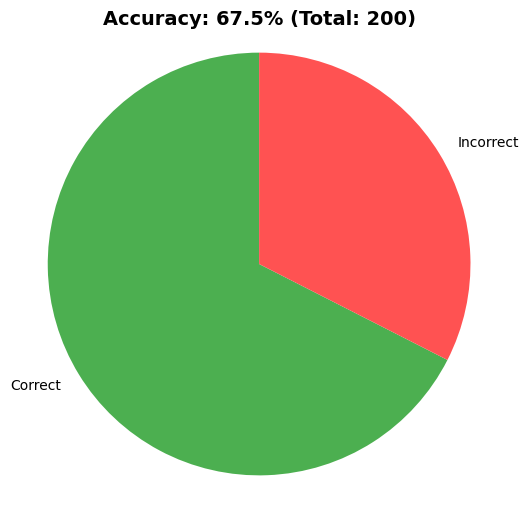

In [16]:
import matplotlib.pyplot as plt
import json

filename = "severity_easy_zero_pred.json" 
evaluate_predictions(filename)
with open(filename, 'r', encoding='utf-8') as f:
    results_data = json.load(f)


total_examples = len(results_data)
count = sum(1 for item in results_data if item['correct'] == True)


accuracy_percentage = (count / total_examples) * 100 if total_examples > 0 else 0
incorrect = total_examples - count

labels = ['Correct', 'Incorrect']
sizes = [count, incorrect]
colors = ['#4CAF50', '#FF5252']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, startangle=90)
plt.title(f'Accuracy: {accuracy_percentage:.1f}% (Total: {total_examples})', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

## Zero shot test - Hard

In [18]:
import json

# ודא שהפונקציות build_severity_input_text ו-classify_severity_zero_shot 
# מוגדרות בתא קודם במחברת (כמו בתשובה הקודמת)

with open('test_hard.json', 'r', encoding='utf-8') as f:
    dataset = json.load(f)

count = 0
total_examples = len(dataset)
results = []

print(f"Starting SEVERITY classification on {total_examples} items...\n")

for i, item in enumerate(dataset):

    # 1. בניית הטקסט המלא עם כל ההקשר (Workflow, User Experience...)
    input_text = build_severity_input_text(item)

    # 2. שליפת ה-Label האמיתי (Severity)
    correct_severity = item['malfunction']['severity']

    # 3. ביצוע הסיווג
    pred, was_right = classify_severity_zero_shot(input_text, correct_severity)

    if was_right:
        count += 1

    results.append({
        "id": item['example_id'],
        "correct": was_right,
        "prediction": pred,
        "truth": correct_severity
    })

# חישוב אחוזי דיוק להדפסה בסוף
accuracy = (count / total_examples) * 100 if total_examples > 0 else 0
print(f"Done classification on {total_examples} items.")
print(f"Final Accuracy: {accuracy:.2f}%")

output_filename = "severity_hard_zero_pred.json"
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=4)

Starting SEVERITY classification on 200 items...

Done classification on 200 items.
Final Accuracy: 67.50%


## Zero shot evaluation - Hard

--- Loading results from: severity_hard_zero_pred.json ---

        EVALUATION REPORT        
Total Examples:       200
Accuracy:             67.50%
-----------------------------------
Precision (weighted): 0.7053
Recall (weighted):    0.6750
F1 Score (weighted):  0.6667
F1 Score (macro):     0.6475


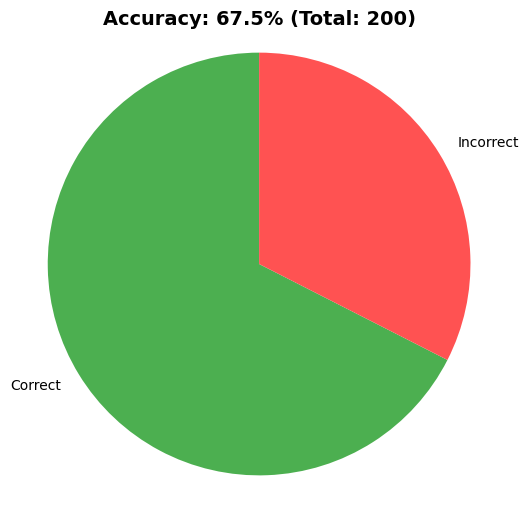

In [20]:
import matplotlib.pyplot as plt
import json

filename = "severity_hard_zero_pred.json" 
evaluate_predictions(filename)
with open(filename, 'r', encoding='utf-8') as f:
    results_data = json.load(f)


total_examples = len(results_data)
count = sum(1 for item in results_data if item['correct'] == True)


accuracy_percentage = (count / total_examples) * 100 if total_examples > 0 else 0
incorrect = total_examples - count

labels = ['Correct', 'Incorrect']
sizes = [count, incorrect]
colors = ['#4CAF50', '#FF5252']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, startangle=90)
plt.title(f'Accuracy: {accuracy_percentage:.1f}% (Total: {total_examples})', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()